### DUMMY VARIABLE


#### Import Libraries required


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#### Import Data set


In [2]:
rawData = pd.read_csv(r'C:\\Users\\DELL\\Desktop\\Dummies.csv')


In [3]:
Data = rawData.copy()

In [4]:
Data.head(5)

,SAT,GPA,Attendance
0,1714,2.40,No
1,1664,2.52,No
2,1760,2.54,No
3,1685,2.74,No
4,1693,2.83,No


In [5]:
Data.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


In [6]:
Data['Attendance'] = Data['Attendance'].map({'Yes':1,'No':0})

In [7]:
Data.head(20)

,SAT,GPA,Attendance
0,1714,2.40,0
1,1664,2.52,0
2,1760,2.54,0
3,1685,2.74,0
4,1693,2.83,0
5,1670,2.91,0
6,1764,3.00,0
7,1764,3.00,0
8,1792,3.01,0
9,1850,3.01,0


In [8]:
Data.describe()

,SAT,GPA,Attendance
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,0.464286
std,104.530661,0.271617,0.501718
min,1634.000000,2.400000,0.000000
25%,1772.000000,3.190000,0.000000
50%,1846.000000,3.380000,0.000000
75%,1934.000000,3.502500,1.000000
max,2050.000000,3.810000,1.000000


#### Regression


In [9]:
y=Data['GPA']

In [10]:
x1=Data[['SAT','Attendance']]

In [11]:
x = sm.add_constant(x1)
results=sm.OLS(y,x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Tue, 13 Aug 2024   Prob (F-statistic):           2.19e-15
Time:                        11:49:15   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   1.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

###### From the P_value of SAT and Attendance, we can conclude that both variables are significant and their constants are 0.0014 and 0.226. Intercept is 0.6439

In [12]:
y_hatYES= 0.8665+0.0014*Data['SAT']
y_hatNO= 0.6439+0.0014*Data['SAT']

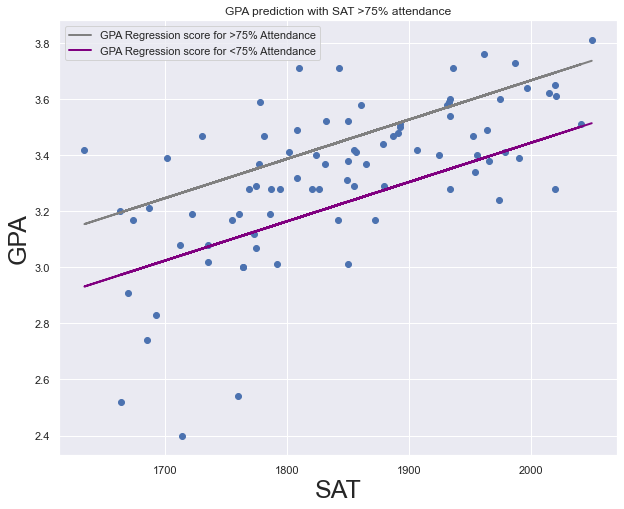

In [13]:
plt.figure(figsize=(10,8))
plt.scatter(Data['SAT'],y)
fig=plt.plot(Data['SAT'],y_hatYES,c='grey',lw=2,label='GPA Regression score for >75% Attendance')
fig=plt.plot(Data['SAT'],y_hatNO,c='purple',lw=2,label='GPA Regression score for <75% Attendance')
plt.xlabel('SAT',fontsize= 25)
plt.ylabel('GPA',fontsize= 25)
plt.legend(loc='upper left')
plt.title('GPA prediction with SAT >75% attendance')
plt.show()

###### Making Predections

In [14]:
x

,const,SAT,Attendance
0,1.0,1714,0
1,1.0,1664,0
2,1.0,1760,0
3,1.0,1685,0
4,1.0,1693,0
...,...,...,...
79,1.0,1936,1
80,1.0,1810,1
81,1.0,1987,0
82,1.0,1962,1


###### x came from , it addedd a constant = 1 which is multiple of intercept x=sm.add_constant(x_1)



In [15]:
new_Data=pd.DataFrame({'const':1,'SAT':[1700,1670],'Attendance':[0,1]})
new_Data

,const,SAT,Attendance
0,1,1700,0
1,1,1670,1


In [16]:
new_Data= new_Data[['const','SAT','Attendance']] # Pandas sort columns in Alphabetical manner

In [17]:
new_Data= new_Data.rename(index={0:'Bob',1:'Alice'})
new_Data

,const,SAT,Attendance
Bob,1,1700,0
Alice,1,1670,1


In [19]:
predictions=results.predict(new_Data)
predictions

Bob      3.023513
Alice    3.204163
dtype: float64

In [21]:
predictionsdf = pd.DataFrame({'Predictions':predictions})
Joined=new_Data.join(predictionsdf)

In [22]:
Joined

,const,SAT,Attendance,Predictions
Bob,1,1700,0,3.023513
Alice,1,1670,1,3.204163


###### The analysis shows how including dummy variables can allow for modeling categorical variables within a regression framework.